# Telco Customer Churn Analysis

This notebook performs exploratory data analysis on the Telco Customer Churn dataset. We will:
- inspect data quality and feature types
- clean and transform the data
- visualize churn patterns across customer segments


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
data_path = "telco_churn.csv"
df = pd.read_csv(data_path)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.drop(columns='customerID', inplace=True)
df.shape


(7043, 20)

In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', ''), errors='coerce')
missing_total = df['TotalCharges'].isna().sum()
if missing_total > 0:
    print(f"TotalCharges has {missing_total} missing values. Filling these with 0 because these records have zero tenure.")
    df['TotalCharges'].fillna(0, inplace=True)

# Convert SeniorCitizen to categorical text for easier interpretation

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
# Add a numeric churn flag for later correlation analysis

df['ChurnFlag'] = df['Churn'].map({'No': 0, 'Yes': 1})


TotalCharges has 11 missing values. Filling these with 0 because these records have zero tenure.


C:\Users\madhusudan kumar\AppData\Local\Temp\ipykernel_22564\3396424260.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [8]:
df.describe()

,tenure,MonthlyCharges,TotalCharges,ChurnFlag
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370
std,24.559481,30.090047,2266.794470,0.441561
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000
max,72.000000,118.750000,8684.800000,1.000000


In [9]:
df['SeniorCitizen']=df['SeniorCitizen'].replace({0:"no",1:"yes"})

In [10]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


C:\Users\madhusudan kumar\AppData\Local\Temp\ipykernel_22564\2339070484.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['#4c72b0', '#dd8452'])


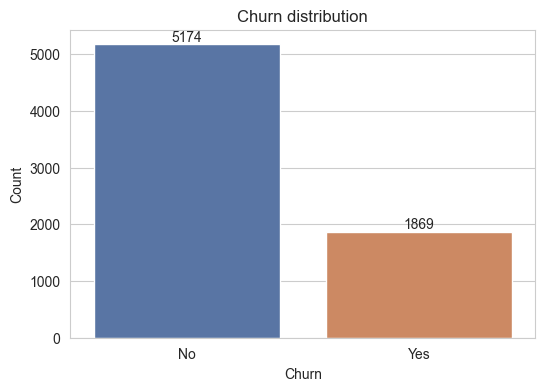

In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette=['#4c72b0', '#dd8452'])
for bar in ax.containers:
    ax.bar_label(bar)
plt.title('Churn distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()


## Insight

- **Churn rate is about 26.5%**, meaning over one quarter of the customer base churned.
- This class imbalance is manageable for exploratory analysis and can guide model selection.


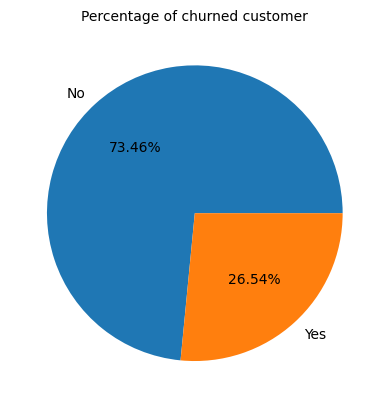

In [ ]:
pie = df['Churn'].value_counts()
labels = pie.index
sizes = pie.values
colors = ['#4c72b0', '#dd8452']
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, explode=(0, 0.05))
plt.title('Percentage of churned customers')
plt.axis('equal')
plt.show()


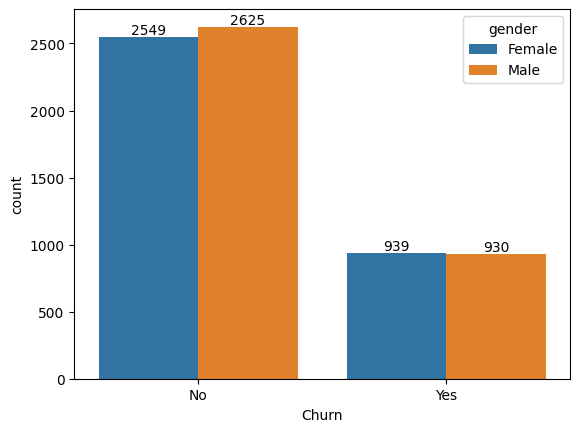

In [ ]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', hue='gender', data=df, palette='pastel')
for bar in ax.containers:
    ax.bar_label(bar)
plt.title('Churn by gender')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()


## Insight

- Gender does not appear to be a strong churn driver in this dataset.
- Male and female customers churn at similar rates.


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


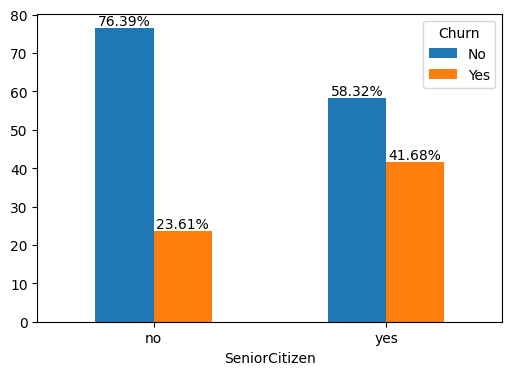

In [ ]:
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
ax = ct.plot(kind='bar', figsize=(6, 4), color=['#4c72b0', '#dd8452'])
for bars in ax.containers:
    ax.bar_label(bars, fmt='%1.2f%%')
plt.xticks(rotation=0)
plt.title('Churn rate by senior citizen status')
plt.ylabel('Percentage')
plt.show()


## Insight

- Senior citizens have a higher churn percentage compared to non-senior customers.
- This suggests targeted retention programs may be especially important for that segment.


In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


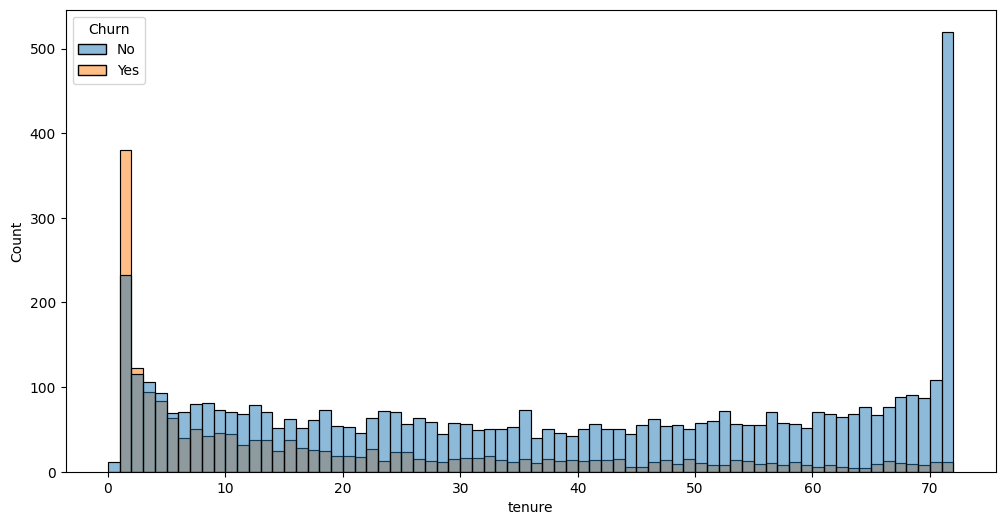

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, palette=['#4c72b0', '#dd8452'])
plt.title('Tenure distribution by churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.show()


## Insight

- Customers with shorter tenure are much more likely to churn.
- The early months are where churn is concentrated, showing the importance of first-year retention.


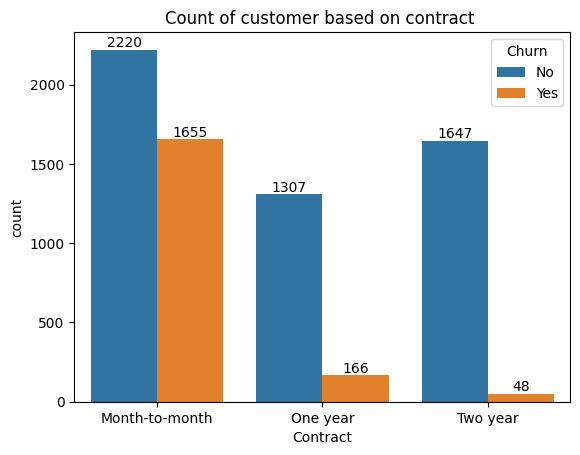

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Contract', data=df, hue='Churn', palette=['#4c72b0', '#dd8452'])
for bar in ax.containers:
    ax.bar_label(bar)
plt.title('Customer count by contract type and churn')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.xticks(rotation=25)
plt.legend(title='Churn')
plt.show()


## Insight

- Month-to-month customers churn at much higher rates than one-year and two-year contracts.
- Long-term contracts are strongly associated with lower churn.


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

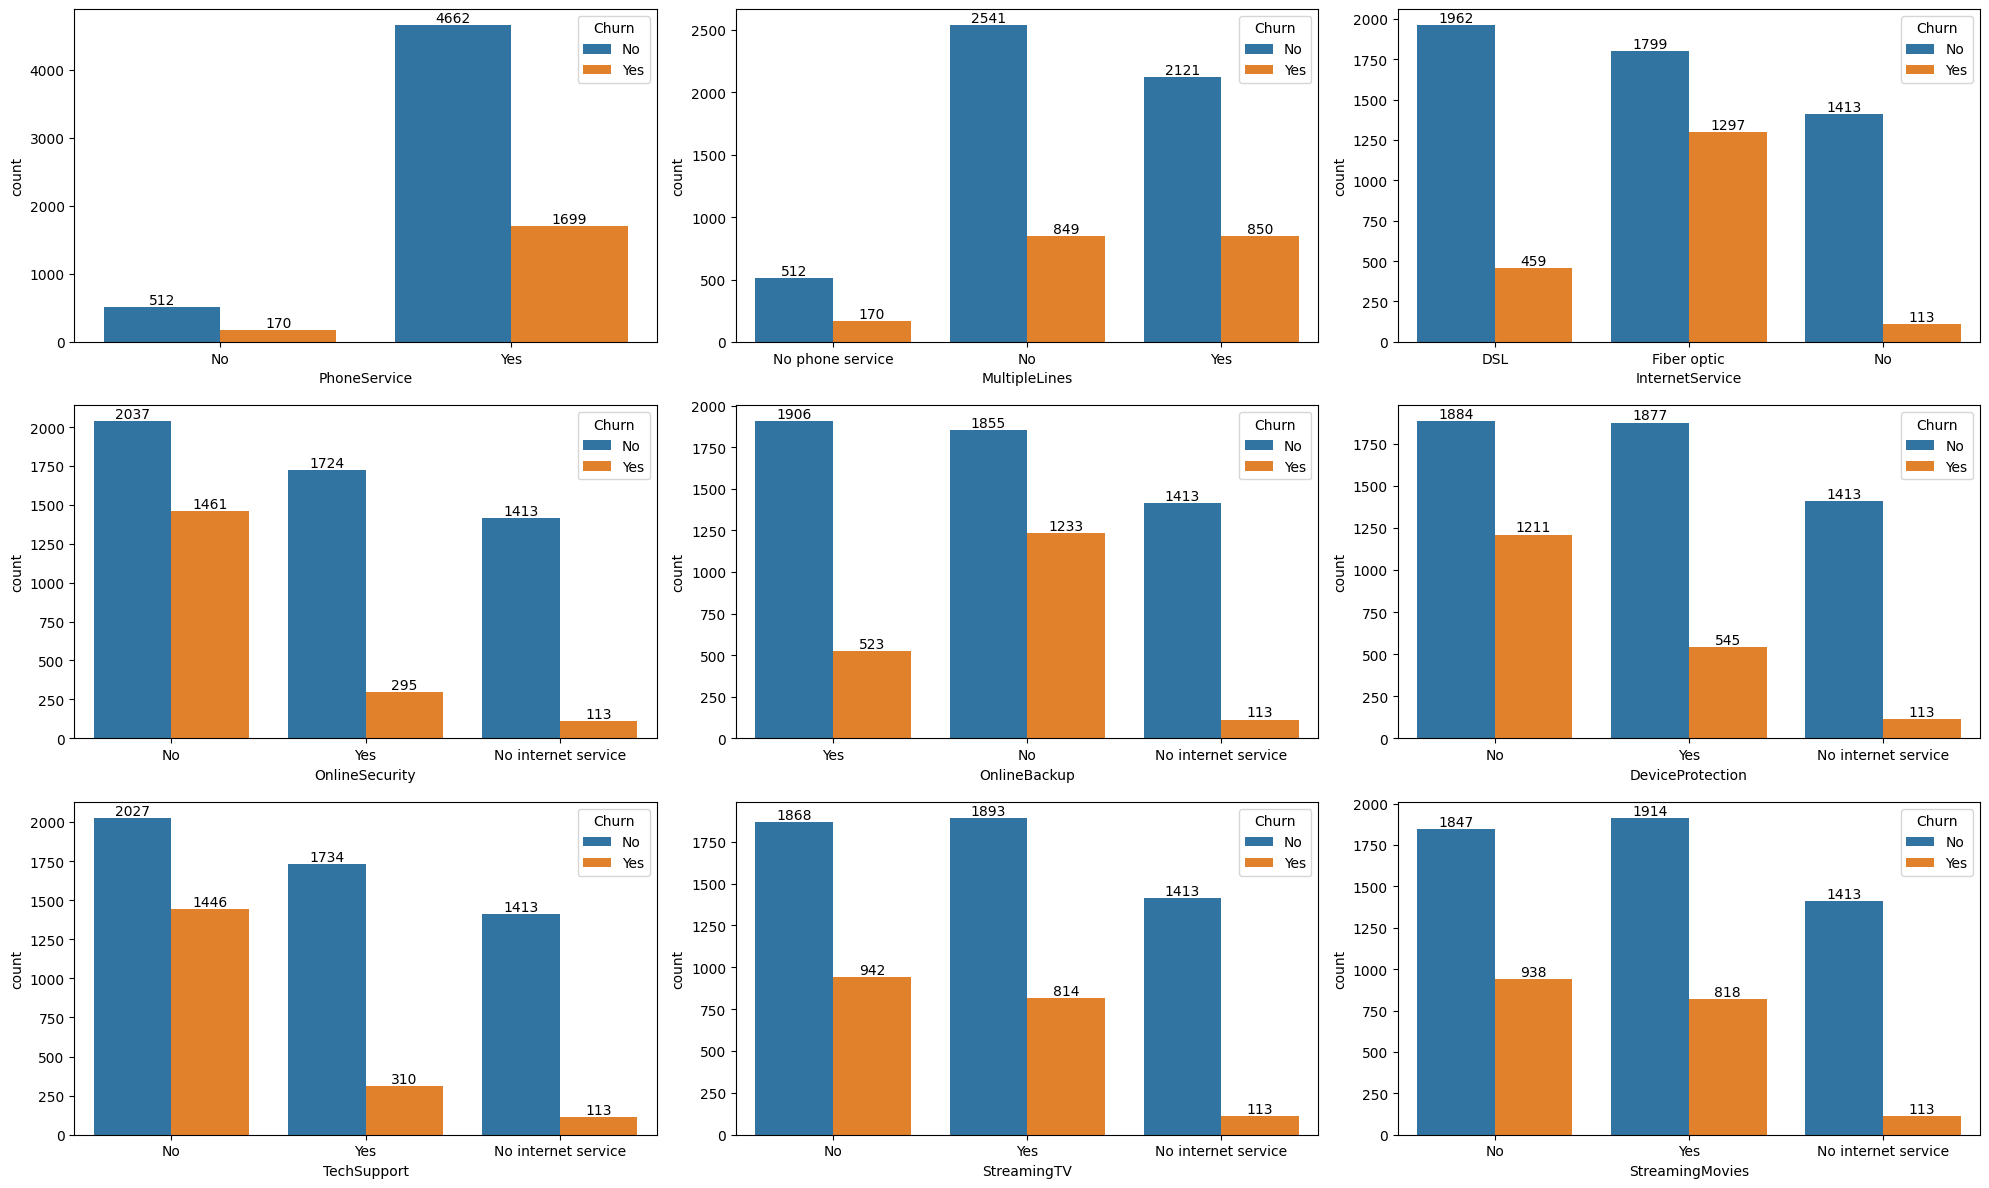

In [ ]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

plt.figure(figsize=(20, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    ax = sns.countplot(x=col, data=df, hue='Churn', palette=['#4c72b0', '#dd8452'])
    plt.xticks(rotation=30)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.title(col)
    for bars in ax.containers:
        ax.bar_label(bars)

plt.tight_layout()
plt.show()


## Insight

- Customers without tech support or online security are more likely to churn.
- Streaming and internet service choices also show clear churn patterns and should be included in modeling.


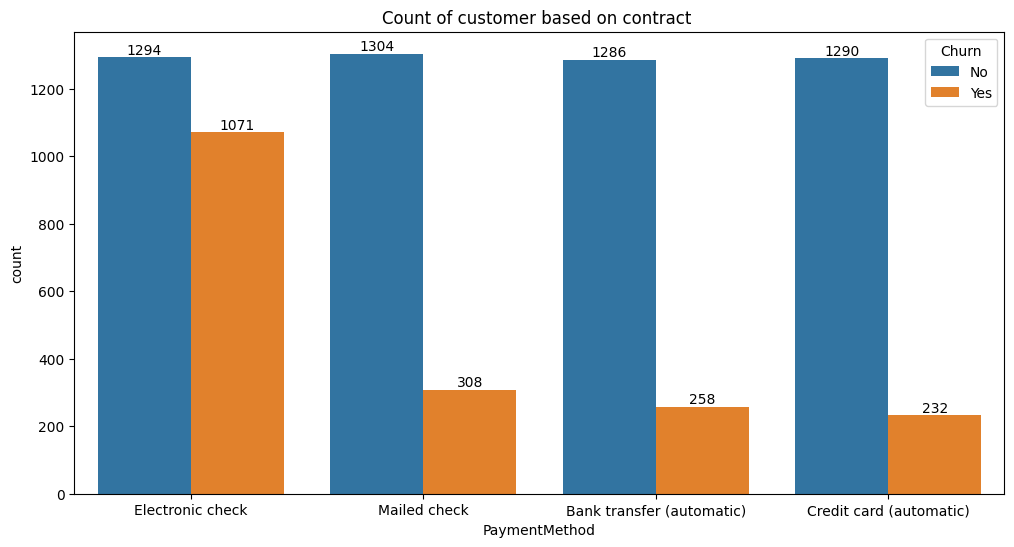

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='PaymentMethod', data=df, hue='Churn', palette=['#4c72b0', '#dd8452'])
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Churn by payment method')
plt.xlabel('Payment method')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Churn')
plt.show()


## Insight

- Customers paying by electronic check demonstrate higher churn levels.
- Payment method should be a strong feature in churn modeling.


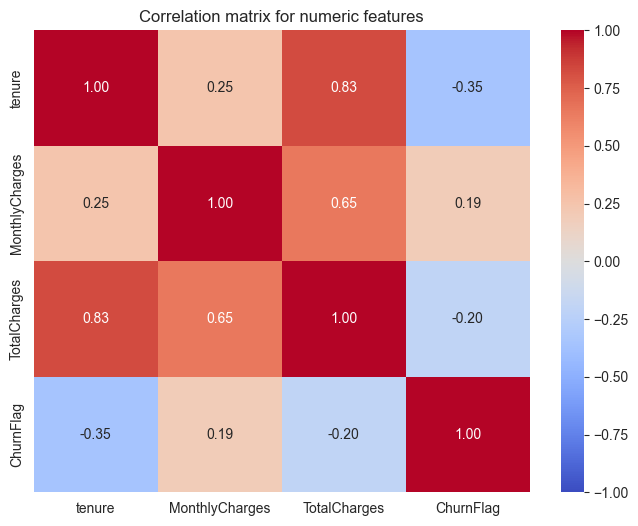

In [14]:
plt.figure(figsize=(8, 6))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'ChurnFlag']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation matrix for numeric features')
plt.show()


## Insight

- Tenure is negatively correlated with churn, confirming that long-term customers are less likely to leave.
- MonthlyCharges has a weak positive correlation with churn, while TotalCharges is negatively correlated because churners tend to have shorter relationships.


## Final Summary

**Portfolio-ready conclusions**

- The churn rate is about 26.5%, so the dataset has enough positive churn examples for modeling.
- Month-to-month contracts, electronic check payments, short tenure, and lack of tech support/online security are the strongest churn signals.
- Senior citizens churn at higher rates than non-senior customers.
- For portfolio quality, add a modeling section next (classification model, feature importance, and business recommendation).
